# 125M1H026_ADS_Ex_Lab_T3_A2
## Movie Ratings Explorer

This notebook analyses the provided `movies.csv` dataset and prepares the Streamlit application for exploring movie ratings by genre.

The application includes:
- loading and previewing the movie dataset
- removing rows with missing values in important columns
- selecting a genre from a dropdown
- summary statistics for the selected genre
- a boxplot comparing ratings across genres
- a Votes vs Rating scatterplot for the selected genre


## 1. Import libraries

Pandas is used for loading and analysing the data. Matplotlib and Seaborn are used to create the required visualisations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and inspect the dataset

The dataset is loaded first and checked for its columns, data types, missing values, and duplicate rows.

In [3]:
movies_data = pd.read_csv("./data/movies.csv")

movies_data.head()

,Title,Genre,Year,Rating,Votes
0,Movie 1,Drama,1996,8.5,3362
1,Movie 2,Action,2010,2.7,4014
2,Movie 3,Action,1998,5.9,1368
3,Movie 4,Action,2015,5.7,9824
4,Movie 5,Drama,2010,9.2,1672


In [4]:
print("Dataset shape:", movies_data.shape)
print("\nColumn data types:")
print(movies_data.dtypes)

print("\nMissing values:")
print(movies_data.isnull().sum())

print("\nDuplicate rows:", movies_data.duplicated().sum())

Dataset shape: (100, 5)

Column data types:
Title         str
Genre         str
Year        int64
Rating    float64
Votes       int64
dtype: object

Missing values:
Title     0
Genre     0
Year      0
Rating    0
Votes     0
dtype: int64

Duplicate rows: 0


### Dataset observations

The provided dataset contains **100 records** and **5 columns**:

- `Title`
- `Genre`
- `Year`
- `Rating`
- `Votes`

The dataset contains four genres: **Action, Comedy, Horror, and Drama**. No missing values or duplicate rows were found in the original dataset.

Even though there are no missing values in this dataset, the cleaning step is still included because it is a required part of the task.

In [5]:
print("Movies per genre:")
print(movies_data["Genre"].value_counts())

print("\nYear range:")
print(movies_data["Year"].min(), "to", movies_data["Year"].max())

Movies per genre:
Genre
Action    32
Comedy    27
Horror    21
Drama     20
Name: count, dtype: int64

Year range:
1990 to 2021


## 3. Drop rows with missing values in key columns

The columns `Genre`, `Year`, `Rating`, and `Votes` are required for the analysis. Rows with missing values in any of these columns are removed.

In [6]:
clean_movies_data = movies_data.dropna(
    subset=["Genre", "Year", "Rating", "Votes"]
).copy()

print("Rows before cleaning:", len(movies_data))
print("Rows after cleaning:", len(clean_movies_data))

Rows before cleaning: 100
Rows after cleaning: 100


## 4. Preview the cleaned dataset

This preview is the same type of data preview that will be available in the Streamlit application.

In [7]:
clean_movies_data.head(10)

,Title,Genre,Year,Rating,Votes
0,Movie 1,Drama,1996,8.5,3362
1,Movie 2,Action,2010,2.7,4014
2,Movie 3,Action,1998,5.9,1368
3,Movie 4,Action,2015,5.7,9824
4,Movie 5,Drama,2010,9.2,1672
5,Movie 6,Drama,2003,7.9,3937
6,Movie 7,Action,2008,6.7,6065
7,Movie 8,Comedy,1996,3.9,3549
8,Movie 9,Comedy,2021,3.3,1431
9,Movie 10,Action,2005,6.0,8444


## 5. Select a genre and calculate summary statistics

For the notebook analysis, one genre is selected manually. In the Streamlit application, the user selects the genre using a dropdown.

The required values are:
- average movie rating
- average number of votes
- median year of release


In [8]:
selected_genre = "Action"

selected_genre_data = clean_movies_data[
    clean_movies_data["Genre"] == selected_genre
]

average_rating = selected_genre_data["Rating"].mean()
average_votes = selected_genre_data["Votes"].mean()
median_release_year = selected_genre_data["Year"].median()

print(f"Selected genre: {selected_genre}")
print(f"Average rating: {average_rating:.2f}")
print(f"Average votes: {average_votes:.2f}")
print(f"Median year of release: {median_release_year:.0f}")

Selected genre: Action
Average rating: 5.57
Average votes: 5577.88
Median year of release: 2008


## 6. Compare movie ratings across all genres

A boxplot is used to compare the distribution of movie ratings for each genre.

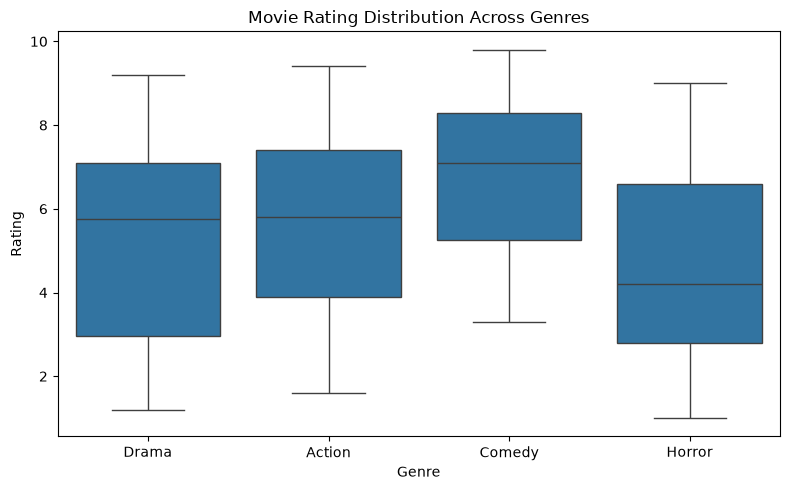

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_movies_data,
    x="Genre",
    y="Rating"
)

plt.title("Movie Rating Distribution Across Genres")
plt.xlabel("Genre")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

## 7. Explore Votes vs Rating for the selected genre

The scatterplot uses:
- `Votes` on the x-axis
- `Rating` on the y-axis
- vote count to control marker size
- rating to control the color gradient

The data is limited to the selected genre.

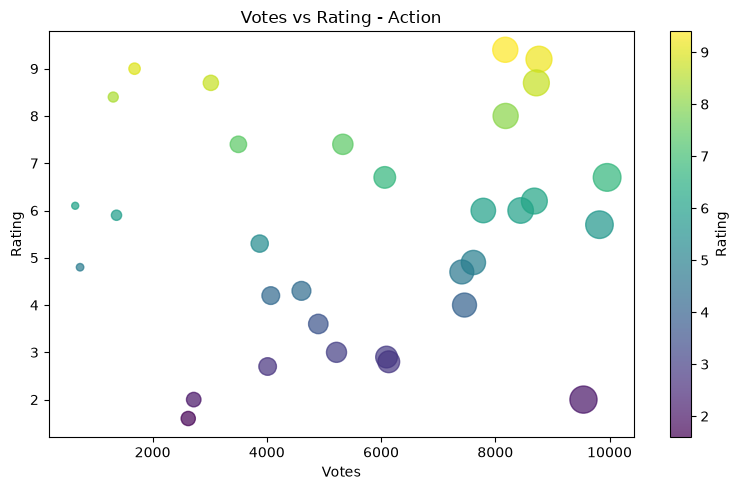

In [10]:
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    selected_genre_data["Votes"],
    selected_genre_data["Rating"],
    s=selected_genre_data["Votes"] / 25,
    c=selected_genre_data["Rating"],
    alpha=0.7
)

plt.colorbar(scatter, label="Rating")
plt.title(f"Votes vs Rating - {selected_genre}")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# Streamlit Web Application

Save the following code as `T3_app.py` in the same folder as `125M1H026_ADS_Ex_Lab_T3_A2`.

Run the application from PowerShell:

`python -m streamlit run .\T3_app.py`


## Conclusion

The dataset was cleaned and explored by genre. The application allows the user to select a genre and immediately view its average rating, average vote count, and median release year. The two charts provide both an overall comparison of ratings across genres and a detailed view of the relationship between votes and ratings within the selected genre.